# M2 - Constitutive laws: elasticity, the tensile test, $S_y$, $S_u$

**Tutoring track, 057922 Nuclear Design and Technology** · Politecnico di Milano

Author: Giovanni Zullo

Run the cells in order, or **Runtime > Run all**.

---

## Contents

1. Hooke's law
2. The plane approximations
3. The thermal term, and the biaxial modulus $E/(1-\nu)$
4. One experiment, two ways to plot it
5. Reading the curve: where is "the" yield stress?
6. Why the UTS is where necking starts: Considère
7. Four questions, four different answers
8. Idealised models, and what each one throws away
9. Two limits of the tensile test
10. Exercises

---
## 1. Hooke's law

For a linear, isotropic, elastic material,

$$\sigma_{ij} = \lambda\,\varepsilon_{kk}\,\delta_{ij} + 2G\,\varepsilon_{ij},$$

with the **Lamé constants** $\lambda$ and $G$ (the latter is the shear modulus, also
written $\mu$, which this course keeps for the attenuation coefficient). Inverting,

$$\varepsilon_{ij} = \frac{1+\nu}{E}\sigma_{ij} - \frac{\nu}{E}\sigma_{kk}\delta_{ij}.$$

> **Notation: the engineering shear strain, and the axes.** For $i \ne j$ the compliance
> law above reads $\varepsilon_{xy} = (1+\nu)\sigma_{xy}/E = \sigma_{xy}/(2G)$. Engineers
> do not quote $\varepsilon_{xy}$ for shear; they quote the **engineering shear strain**
> $$\gamma_{xy} = 2\,\varepsilon_{xy}, \qquad\text{so that}\qquad \tau_{xy} = G\,\gamma_{xy}.$$
> $\gamma_{xy}$ is the whole change of the right angle between two fibres initially along
> $x$ and $y$; the tensor component $\varepsilon_{xy}$ is half of it, because the tensor
> shares that change equally between the two directions. It is why $G$ carries no 2 in
> $\tau = G\gamma$ and carries one in
> $\sigma_{ij} = \lambda\varepsilon_{kk}\delta_{ij} + 2G\varepsilon_{ij}$, and why a
> finite-element code reporting "shear strain" has to be asked which of the two it means.
>
> While here: from now on the axes are $x,y,z$ rather than $x_1,x_2,x_3$, so
> $\sigma_{11}$ is $\sigma_{xx}$ and $\varepsilon_{12}$ is $\varepsilon_{xy}$.

The engineering constants and the Lamé constants are two parametrisations of the same
two numbers:

$$G = \frac{E}{2(1+\nu)},\qquad
\lambda = \frac{E\nu}{(1+\nu)(1-2\nu)},\qquad
K = \frac{E}{3(1-2\nu)}.$$

Two consequences of isotropy. The law splits into a
**volumetric** and a **deviatoric** part that do not talk to each other,

$$\sigma_m = K\,\varepsilon_{kk}, \qquad s_{ij} = 2G\,e_{ij},
\qquad e_{ij} = \varepsilon_{ij} - \tfrac13\varepsilon_{kk}\delta_{ij},$$

so the mean stress changes only the volume and the deviator only the shape. And since a
shear strain produces only the matching shear stress, the axes that make the strain
diagonal make the stress diagonal too: **the principal directions of stress and strain
coincide**.

**Read the denominators.** As $\nu \to 1/2$ both $\lambda$ and the bulk modulus $K$ blow
up: the material becomes incompressible. Nothing is wrong with the physics, but
displacement-based finite elements struggle there, and this is the origin of *volumetric
locking*, which the FEM sessions of the course will meet head-on. Steel at $\nu = 0.3$
is comfortably away from it; nearly-incompressible materials are not. And $\nu$ cannot
go past $1/2$ at all: the stored energy of the next paragraph has to be positive for every
strain, and that holds only if $K > 0$ and $G > 0$, that is $-1 < \nu < 1/2$.

**Where the law comes from.** An elastic material stores the work done on it and gives it
back. Call $U_0(\varepsilon)$ that stored energy per unit volume; the stress is its
gradient,

$$\sigma_{ij} = \frac{\partial U_0}{\partial \varepsilon_{ij}},$$

so the stiffness $C_{ijkl} = \partial^2 U_0/\partial\varepsilon_{ij}\partial\varepsilon_{kl}$
is a second derivative and does not care in which order it is taken:
$C_{ijkl} = C_{klij}$. That one fact cuts the general anisotropic law from 36 constants to
**21**, before any symmetry of the material is invoked. For a linear material
$U_0 = \tfrac12\sigma_{ij}\varepsilon_{ij}$, which is the **area under the
stress-strain curve**. Taken as far as yield it is the **modulus of resilience**, the
energy the material gives back on unloading; taken past yield the same area is what §7
calls toughness, and that part is not given back.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
trapz = getattr(np, "trapezoid", None) or np.trapz   # renamed in NumPy 2.0
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.figsize': (6.5, 6.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

E, nu = 200e9, 0.30                      # Pa, -   neutral steel
G   = E/(2*(1+nu))
lam = E*nu/((1+nu)*(1-2*nu))
K   = E/(3*(1-2*nu))
print(f'E = {E/1e9:.1f} GPa,  nu = {nu}')
print(f'G = {G/1e9:.2f} GPa,  lambda = {lam/1e9:.2f} GPa,  K = {K/1e9:.2f} GPa')

def hooke(eps, lam, G):
    return lam*np.trace(eps)*np.eye(3) + 2*G*eps

def hooke_inv(sig, E, nu):
    return (1+nu)/E*sig - nu/E*np.trace(sig)*np.eye(3)

eps = np.array([[ 1.0e-3, 2.0e-4, 0.0],
                [ 2.0e-4,-5.0e-4, 1.0e-4],
                [ 0.0,    1.0e-4, 3.0e-4]])
sig = hooke(eps, lam, G)
print('\nstress from strain (MPa):'); print(sig/1e6)
print(f'round trip, max |eps - C^-1 C eps| = {np.abs(hooke_inv(sig, E, nu) - eps).max():.2e}')

# Silent guard on the volumetric/deviatoric split stated above: sigma_m = K eps_kk, s = 2G e.
_dev = lambda A: A - np.trace(A)/3*np.eye(3)
assert np.isclose(np.trace(sig)/3, K*np.trace(eps)) and np.allclose(_dev(sig), 2*G*_dev(eps))

print('\nincompressibility limit:')
for v in [0.30, 0.45, 0.499, 0.4999]:
    print(f'   nu = {v:6.4f}:  lambda = {E*v/((1+v)*(1-2*v))/1e9:12.1f} GPa,'
          f'  K = {E/(3*(1-2*v))/1e9:12.1f} GPa')

E = 200.0 GPa,  nu = 0.3
G = 76.92 GPa,  lambda = 115.38 GPa,  K = 166.67 GPa

stress from strain (MPa):
[[246.1538  30.7692   0.    ]
 [ 30.7692  15.3846  15.3846]
 [  0.      15.3846 138.4615]]
round trip, max |eps - C^-1 C eps| = 2.17e-19

incompressibility limit:
   nu = 0.3000:  lambda =        115.4 GPa,  K =        166.7 GPa
   nu = 0.4500:  lambda =        620.7 GPa,  K =        666.7 GPa
   nu = 0.4990:  lambda =      33288.9 GPa,  K =      33333.3 GPa
   nu = 0.4999:  lambda =     333288.9 GPa,  K =     333333.3 GPa


---
## 2. The plane approximations

Real components are 3-D. Almost every hand calculation in this course reduces them to
2-D by assuming something about the third direction. There are three standard choices,
and picking the wrong one is a common and expensive mistake.

| | Assumption | Appropriate when | Consequence |
|---|---|---|---|
| **Plane stress** | $\sigma_{zz} = 0$ | thin plate, free faces | $\varepsilon_{zz} \ne 0$, free to thin |
| **Plane strain** | $\varepsilon_{zz} = 0$ | long body, fully restrained ends | $\sigma_{zz} = \nu(\sigma_{xx}+\sigma_{yy}) \ne 0$ |
| **Generalised plane strain** | $\varepsilon_{zz} = $ const, unknown | long body, free ends, axial resultant prescribed | the constant is found from $\int\sigma_{zz}dA = N$ |

For a uniform state **and $N = 0$** the third case is not a third answer: zero net axial
force over a uniform section means $\sigma_{zz}=0$ pointwise, which is plane stress. Generalised plane
strain differs only when the field **varies over the section**, as it does under a
temperature gradient.

The first two are not equally exact. **Plane strain** is an exact solution of the 3-D
problem whenever the ends are held against axial motion, by smooth rigid planes for
instance. **Plane stress** is an approximation: the $\varepsilon_{zz}$ it produces is in
general not compatible (the "fit together" condition), so the solution satisfies
equilibrium but not compatibility, and its in-plane stresses are to be read as averages
over the thickness of a thin plate.


![The three plane hypotheses side by side, each with its own out-of-plane axis drawn: a thin plate with z through the thickness and free faces; a long body with z along it and its ends held; a long cylinder with z along the axis and its ends free. What is imposed is in red, what follows in blue.](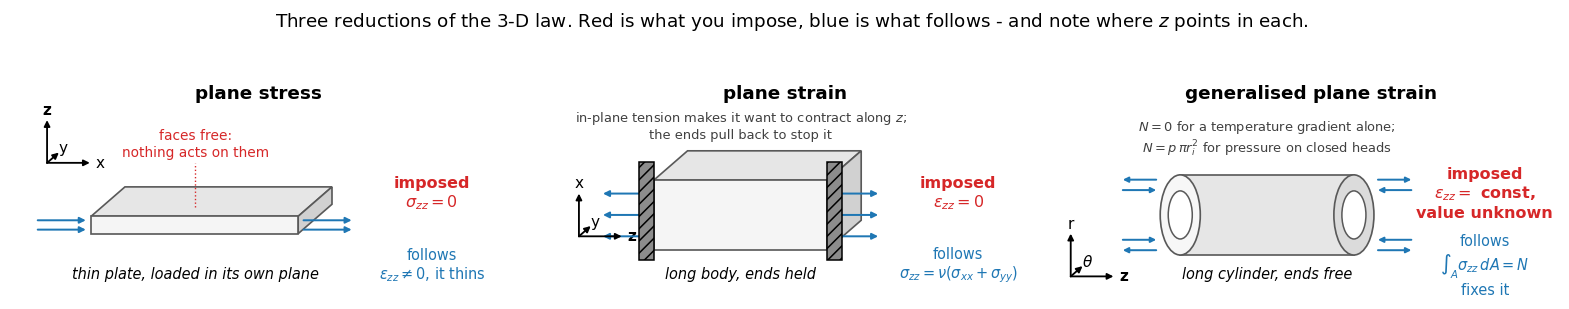)

*The three reductions, and where $z$ points in each. Red is the hypothesis you impose, blue what follows from it. The axis that leaves the plane is different in the three cases, and assuming it is always the vertical one is how the wrong reduction gets picked. Drawn by `figures/make_figures.py`.*


**A reactor vessel is the third case**, with $z$ along the vessel axis. Far from the
heads, at distances large compared with $\sqrt{rt}$, where $r$ is the radius and $t$ the
wall thickness, sections stay plane;
but its ends are not held by anything, so the axial strain is not zero. It takes the value
that makes the axial resultant match what the loading actually applies:

$$\int_A \sigma_{zz}\,dA = N, \qquad
N = 0 \;\text{for a temperature gradient alone}, \qquad
N = p\,\pi r_i^{2} \;\text{for internal pressure on closed heads.}$$

The constant $\varepsilon_{zz}$ follows from that condition. Assuming plane strain instead
invents an axial restraint that does not exist, and **the sign of the resulting error
depends on the load**. Under a temperature gradient, $N = 0$, plane strain overestimates
$\sigma_{zz}$. Under pressure it underestimates it: for a thick cylinder
$\sigma_{rr}+\sigma_{\theta\theta} = 2A$ with $A = pr_i^2/(r_o^2-r_i^2)$, so plane strain
returns $\sigma_{zz} = 2\nu A = 0.6\,A$ against the closed-end value $A$ - forty per cent
low, and on the unsafe side. Harvey works the thick cylinder and the end effect out in
full; Corradi Dell'Acqua (§4.3.2) solves the thick cylinder in plane strain and
finds the same $2\nu A$.

The effective in-plane stiffness differs between the first two. For **equal biaxial**
strain,

$$\text{plane stress:}\;\; \sigma = \frac{E}{1-\nu}\,\varepsilon,
\qquad
\text{plane strain:}\;\; \sigma = \frac{E}{(1+\nu)(1-2\nu)}\,\varepsilon .$$

Their ratio is $(1-\nu)/[(1+\nu)(1-2\nu)]$, which for steel at $\nu = 0.3$ is **1.35**,
a 35 % difference, not a detail.

**There are four such moduli, and they get quoted for one another.** Which one you need
depends on two choices, not one: the plane hypothesis, *and* how many in-plane directions
are being stretched. Values for $E = 200$ GPa, $\nu = 0.3$:

| | one strain component, $\varepsilon_{yy}=0$ | equal biaxial, $\varepsilon_{xx}=\varepsilon_{yy}$ |
|---|---|---|
| **plane stress**, $\sigma_{zz}=0$ | $\lambda^{*}+2G = \dfrac{E}{1-\nu^{2}} = 219.8$ GPa | $2(\lambda^{*}+G) = \dfrac{E}{1-\nu} = 285.7$ GPa |
| **plane strain**, $\varepsilon_{zz}=0$ | $\lambda+2G = \dfrac{E(1-\nu)}{(1+\nu)(1-2\nu)} = 269.2$ GPa | $2(\lambda+G) = \dfrac{E}{(1+\nu)(1-2\nu)} = 384.6$ GPa |

The display above compares the **right-hand column**, and that is the column this course
uses. The left column is not wrong, it is right somewhere else: $E/(1-\nu^{2})$ is plane stress
with the second in-plane direction held, which is the modulus of a wide beam and the one
inside the plate bending stiffness $D = Et^{3}/[12(1-\nu^{2})]$; the **oedometric** modulus
is the same restraint under plane strain, the one a laterally confined column of material
feels. They go wrong only when quoted for an equal-biaxial problem. And none of the four
is $E$: one genuinely isolated stress component, everything else free, gives
$\sigma_{xx} = E\varepsilon_{xx}$.

In [2]:
def plane_stress_biaxial(eps_xx, eps_yy, E, nu):
    """sigma_zz = 0 imposed; returns (sxx, syy, eps_zz)."""
    c = E/(1-nu**2)
    sxx = c*(eps_xx + nu*eps_yy)
    syy = c*(eps_yy + nu*eps_xx)
    eps_zz = -nu/E*(sxx + syy)
    return sxx, syy, eps_zz

def plane_strain_biaxial(eps_xx, eps_yy, E, nu):
    """eps_zz = 0 imposed; returns (sxx, syy, szz)."""
    lam_ = E*nu/((1+nu)*(1-2*nu)); G_ = E/(2*(1+nu))
    tr = eps_xx + eps_yy
    return lam_*tr + 2*G_*eps_xx, lam_*tr + 2*G_*eps_yy, lam_*tr

e = 1.0e-3
sx1, sy1, ezz1 = plane_stress_biaxial(e, e, E, nu)
sx2, sy2, szz2 = plane_strain_biaxial(e, e, E, nu)

print(f'equal biaxial strain eps = {e:.0e}')
print(f'  plane stress: sxx = {sx1/1e6:7.1f} MPa,  szz = 0,          eps_zz = {ezz1:.3e}')
print(f'  plane strain: sxx = {sx2/1e6:7.1f} MPa,  szz = {szz2/1e6:6.1f} MPa,  eps_zz = 0')
print(f'\n  plane stress, equal biaxial:  E/(1-nu)           = {E/(1-nu)/1e9:7.2f} GPa')
print(f'  plane strain, equal biaxial:  E/((1+nu)(1-2nu))  = {E/((1+nu)*(1-2*nu))/1e9:7.2f} GPa')
print(f'  (these ARE the two effective moduli: {sx1/e/1e9:.2f} and {sx2/e/1e9:.2f} GPa from above)')
print(f'  ratio = {(sx2/sx1):.3f}  -> {100*(sx2/sx1-1):.0f}% stiffer in plane strain')

# Independent check: feed each result back through the 3D compliance law and see whether
# the hypothesis that was IMPOSED actually comes out. This is a check, not a restatement.
def eps_from_sigma(sxx, syy, szz, E, nu):
    return [(s - nu*(t + u))/E for s, t, u in
            ((sxx, syy, szz), (syy, szz, sxx), (szz, sxx, syy))]

_, _, ezz_chk = eps_from_sigma(sx1, sy1, 0.0, E, nu)          # plane stress
exx3, eyy3, ezz3 = eps_from_sigma(sx2, sy2, szz2, E, nu)      # plane strain
print('\nfeed the answers back through the 3D law:')
print(f'  plane stress: eps_zz recovered = {ezz_chk:.4e}  (imposed sigma_zz = 0)')
print(f'  plane strain: eps_zz recovered = {ezz3:.2e}  -> the imposed 0, to rounding')
print(f'                eps_xx recovered = {exx3:.4e}  vs the {e:.1e} put in')

equal biaxial strain eps = 1e-03
  plane stress: sxx =   285.7 MPa,  szz = 0,          eps_zz = -8.571e-04
  plane strain: sxx =   384.6 MPa,  szz =  230.8 MPa,  eps_zz = 0

  plane stress, equal biaxial:  E/(1-nu)           =  285.71 GPa
  plane strain, equal biaxial:  E/((1+nu)(1-2nu))  =  384.62 GPa
  (these ARE the two effective moduli: 285.71 and 384.62 GPa from above)
  ratio = 1.346  -> 35% stiffer in plane strain

feed the answers back through the 3D law:
  plane stress: eps_zz recovered = -8.5714e-04  (imposed sigma_zz = 0)
  plane strain: eps_zz recovered = 0.00e+00  -> the imposed 0, to rounding
                eps_xx recovered = 1.0000e-03  vs the 1.0e-03 put in


> **Aside: where $\lambda^*$ and $E/(1-\nu^2)$ come from.** *Optional. These are the
> plane-stress constants of the **left** column of the table above, one strain component
> held; not the equal-biaxial moduli of the right column.*
>
> Write Hooke's law in **stiffness** form ($\sigma = f(\varepsilon)$, natural for
> $\lambda,G$) and in **compliance** form ($\varepsilon = f(\sigma)$, natural for
> $E,\nu$). Each plane hypothesis is "free" in one form and "costs" in the other:
>
> | hypothesis | type | stiffness $\sigma=f(\varepsilon)$ | compliance $\varepsilon=f(\sigma)$ |
> |---|---|---|---|
> | $\varepsilon_z=0$ (plane strain) | kinematic | **free**, use $\lambda,G$ | costs, condense $\sigma_z$ |
> | $\sigma_z=0$ (plane stress) | static | costs, condense $\varepsilon_z$ | **free**, use $E,\nu$ |
>
> **Plane strain, condensing the costly side.** Impose $\varepsilon_z=0$ directly in the
> stiffness form: $\sigma_{ij}=\lambda\varepsilon_{kk}\delta_{ij}+2G\varepsilon_{ij}$
> with $\varepsilon_{kk}=\varepsilon_x+\varepsilon_y$ needs no substitution, and that is
> why this side is "free".
>
> **Plane stress, condensing the costly side.** Now impose $\sigma_z=0$ inside the same
> stiffness form:
> $$\sigma_z=\lambda(\varepsilon_x+\varepsilon_y)+(\lambda+2G)\varepsilon_z=0
> \;\Rightarrow\;
> \varepsilon_z=-\frac{\lambda}{\lambda+2G}(\varepsilon_x+\varepsilon_y).$$
> Substituting back into $\sigma_x,\sigma_y$ replaces $\lambda$ everywhere by an
> **effective** Lamé constant,
> $$\boxed{\;\lambda^{*}=\frac{2\lambda G}{\lambda+2G}<\lambda\;}$$
> It is smaller than $\lambda$, because plane stress removes the $z$-direction's
> contribution to the Poisson coupling.
>
> **The bridge to $E/(1-\nu^2)$.** Substituting $\lambda,G$ in terms of $E,\nu$ shows
> $$\lambda^{*}+2G=\frac{4G(\lambda+G)}{\lambda+2G}=\frac{E}{1-\nu^2},
> \qquad
> \lambda^{*}=\frac{\nu E}{1-\nu^2}.$$
> So $E/(1-\nu^2)$ **is** $\lambda^{*}+2G$: the top-left entry of the table in §2, plane
> stress with one strain component held. Its partner one row down is $\lambda+2G$, the
> oedometric modulus. They are a **column**, not a pair with $E/[(1+\nu)(1-2\nu)]$, which
> sits in the other column with $E/(1-\nu)$.
>
> The $E,\nu$ route reaches the same number without condensing anything: in the compliance
> form you set $\sigma_z=0$, invert the $2\times2$ block that is left, and $\varepsilon_z$
> comes out as a result rather than being eliminated. That is what "free" means on that
> side. Two routes, one number: $\lambda^{*}+2G$ written in Lamé constants and
> $E/(1-\nu^{2})$ written in engineering ones are the same 219.8 GPa, and they look
> unlike each other only because of which variable each form had to carry.


---
## 3. The thermal term, and the biaxial modulus $E/(1-\nu)$

A temperature change adds an isotropic strain that carries no stress by itself:

$$\varepsilon_{ij} = \frac{1+\nu}{E}\sigma_{ij} - \frac{\nu}{E}\sigma_{kk}\delta_{ij}
+ \alpha\,\Delta T\,\delta_{ij}.$$

Take a plate with $T(x)$ through the thickness:
$\sigma_{xx} = 0$ (free faces, from equilibrium), and in-plane symmetry gives
$\sigma_{yy} = \sigma_{zz} = \sigma$. Substituting,

$$\varepsilon_{yy} = \frac{1}{E}\big[\sigma - \nu(0 + \sigma)\big] + \alpha\Delta T
= \frac{1-\nu}{E}\sigma + \alpha\Delta T
\quad\Longrightarrow\quad
\boxed{\;\sigma = \frac{E}{1-\nu}\big(\varepsilon_{yy} - \alpha\Delta T\big)\;}$$

That factor $E/(1-\nu)$ is simply **the
biaxial modulus**: the stiffness felt by a material that is being stretched equally in
two directions while free in the third. It is stiffer than $E$ because the Poisson
contraction from each direction is opposed by the stretch in the other.

It is *not* $E/(1-\nu^2)$, which is plane stress with the second in-plane direction
**held** ($\varepsilon_{yy}=0$) rather than stretched with the first. The table in §2 has
the two side by side, and confusing them is a routine error.

In [3]:
alpha = 1.2e-5
dT = 100.0

# plate with free faces (sigma_xx = 0), held in-plane, equal biaxial
biaxial_modulus = E/(1-nu)
eps_yy = 0.0                       # in-plane expansion fully prevented
sig_th = biaxial_modulus*(eps_yy - alpha*dT)

print(f'biaxial modulus E/(1-nu) = {biaxial_modulus/1e9:.2f} GPa   (vs E = {E/1e9:.0f} GPa)')
print(f'restrained plate, dT = {dT} K  ->  sigma = {sig_th/1e6:.1f} MPa')

# Independent check: do not reuse the closed form. Take the 3D compliance law
# eps_ij = (1+nu)/E sig_ij - nu/E sig_kk delta_ij + alpha dT delta_ij, impose
# sxx = 0 and eps_yy = eps_zz = 0, and solve the 2x2 system for syy and szz.
from numpy.linalg import solve
A = np.array([[1.0, -nu], [-nu, 1.0]])
b = np.array([-E*alpha*dT, -E*alpha*dT])
syy, szz = solve(A, b)
print(f'\nsolving the 3D law instead: syy = {syy/1e6:.1f} MPa, szz = {szz/1e6:.1f} MPa')
print(f'agreement with E/(1-nu)(0 - alpha dT): {abs(syy - sig_th):.3e} Pa')

# The free direction takes MORE than the thermal strain: on top of alpha dT it picks up
# the Poisson response to the two in-plane compressions. The factor is (1+nu)/(1-nu).
eps_xx = (0.0 - nu*(syy + szz))/E + alpha*dT
print(f'the free faces move: eps_xx = {eps_xx:.3e} (the plate thickens)')
print(f'   that is {eps_xx/(alpha*dT):.2f} x the free thermal strain alpha dT ='
      f' {alpha*dT:.3e},')
print(f'   and {(1+nu)/(1-nu):.2f} is exactly (1+nu)/(1-nu)')
print(f'\ncompare a bar held at both ends, the UNIAXIAL constraint: -E alpha dT ='
      f' {-E*alpha*dT/1e6:.1f} MPa')
print(f'   -> biaxial constraint is {1/(1-nu):.3f}x more severe than uniaxial')

biaxial modulus E/(1-nu) = 285.71 GPa   (vs E = 200 GPa)
restrained plate, dT = 100.0 K  ->  sigma = -342.9 MPa

solving the 3D law instead: syy = -342.9 MPa, szz = -342.9 MPa
agreement with E/(1-nu)(0 - alpha dT): 0.000e+00 Pa
the free faces move: eps_xx = 2.229e-03 (the plate thickens)
   that is 1.86 x the free thermal strain alpha dT = 1.200e-03,
   and 1.86 is exactly (1+nu)/(1-nu)

compare a bar held at both ends, the UNIAXIAL constraint: -E alpha dT = -240.0 MPa
   -> biaxial constraint is 1.429x more severe than uniaxial


---
## 4. One experiment, two ways to plot it

Pull a bar of initial length $L_0$ and initial section $A_0$. You measure force $F$ and
elongation $\Delta L$. To get a stress and a strain you must divide by *something*, and
there are two defensible choices:

| | stress | strain |
|---|---|---|
| **engineering** | $\sigma_e = F/A_0$ | $\varepsilon_e = \Delta L/L_0$ |
| **true** | $\sigma_t = F/A$ | $\varepsilon_t = \int dL/L = \ln(1+\varepsilon_e)$ |

The engineering pair uses the *original* geometry, the true pair the *current* one. The
two conversions do not rest on the same hypothesis:

$$\varepsilon_t = \ln(1+\varepsilon_e) \quad\text{needs only uniform deformation,}$$

$$\sigma_t = \sigma_e\,(1+\varepsilon_e) \quad\text{needs also constant volume, }
A_0L_0 = AL.$$

Constant volume is a **plastic** statement: plastic flow conserves volume, elastic
straining does not, since $\nu = 0.3$ and not $0.5$. In the elastic range the second
formula is therefore approximate, which costs nothing because there the two pairs
coincide anyway.

Two things follow, and both matter later.

**First**, at small strain the two coincide, which is exactly why the whole of
elasticity, and every formula in this course that uses $E$, never has to make the
distinction. **Second**, the conversion above is valid *only up to necking*: once
deformation localises there is no single representative $A$, and the global
$\varepsilon_e$ still measures the total elongation but no longer describes the neck.

In [4]:
print(f"{'eps_eng':>9}{'eps_true':>10}{'difference':>12}{'sigma_t/sigma_e':>18}")
for ee in (0.002, 0.01, 0.05, 0.10, 0.20, 0.40):
    et = np.log(1 + ee)
    print(f"{ee:9.3f}{et:10.4f}{100*(ee/et - 1):11.1f} %{1+ee:18.3f}")

print("\nBelow ~1 % strain they agree to better than 0.5 %.")
print("That is the reason small-strain elasticity never needs the distinction,")
print("and the reason it becomes unavoidable the moment you go plastic.")

  eps_eng  eps_true  difference   sigma_t/sigma_e
    0.002    0.0020        0.1 %             1.002
    0.010    0.0100        0.5 %             1.010
    0.050    0.0488        2.5 %             1.050
    0.100    0.0953        4.9 %             1.100
    0.200    0.1823        9.7 %             1.200
    0.400    0.3365       18.9 %             1.400

Below ~1 % strain they agree to better than 0.5 %.
That is the reason small-strain elasticity never needs the distinction,
and the reason it becomes unavoidable the moment you go plastic.


---
## 5. Reading the curve: where is "the" yield stress?

A metal does not announce its yield point. The stress-strain curve bends over gradually,
so "where linearity ends" is not measurable: it depends on how good your extensometer
is. The engineering answer is a **convention**:

> $R_{p0.2}$ (or $S_y$) is the stress at which the **residual plastic strain after
> unloading** is $0.2\%$.

Three names for one number: $R_{p0.2}$ is the test standard's, $S_y$ is ASME's, and
$\sigma_y$ is what a constitutive law calls it. This notebook uses all three for that one
number, with one exception it will flag when it comes: a constitutive law is free to
define its own $\sigma_y$ differently, and the Ludwik law of §8 does exactly that, taking
it as the stress at zero plastic strain rather than at the 0.2 % offset.

Graphically: draw a line of slope $E$ through $\varepsilon = 0.002$ and see where it
cuts the curve. It is not "the stress at 0.2 % strain", and it is not the proportional
limit: it is a chosen, reproducible offset.

The **Ramberg-Osgood** law makes this transparent, because it is *built* around the
convention:

$$\varepsilon = \frac{\sigma}{E} + 0.002\left(\frac{\sigma}{\sigma_y}\right)^n$$

The second term is the plastic strain, and at $\sigma = \sigma_y$ it equals $0.002$ by
construction. So $\sigma_y$ in this law is not a fitted parameter that happens to be
near the knee: **it is the 0.2 % offset stress, exactly**.

Ramberg and Osgood's own 1943 note does not write it this way: their three parameters are
Young's modulus and **two secant yield strengths**, not an offset. The form above is the
engineering variant that later took their name, rebuilt around the 0.2 % convention. They
do connect the two, remarking that their $s_1$ corresponds roughly to the 0.2 % offset.

Let us verify that the graphical construction returns $\sigma_y$.

plastic strain at sigma = sy : 0.002000   (0.002 by construction)
0.2 % offset construction   : sigma = 250.0000 MPa
                              input sy = 250.0 MPa  -> they agree exactly


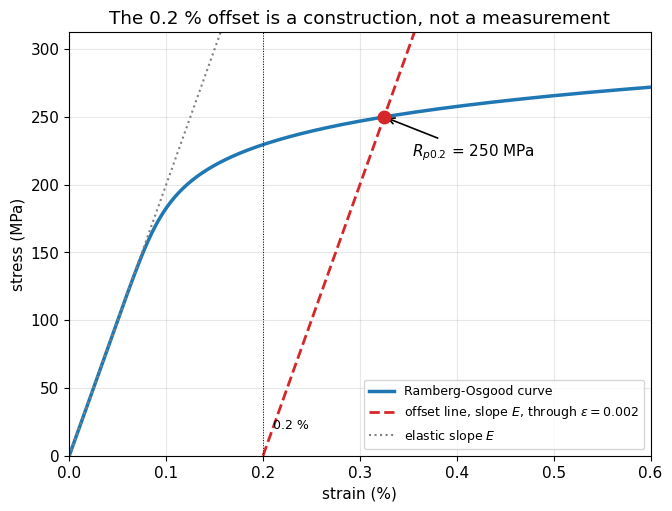

In [5]:
sy, n_ro = 250e6, 10.0          # E comes from the setup cell: change it there once
eps_ro = lambda s: s/E + 0.002*(s/sy)**n_ro

print(f"plastic strain at sigma = sy : {eps_ro(sy) - sy/E:.6f}   (0.002 by construction)")

# the graphical construction: intersect the curve with  eps = sigma/E + 0.002
s_off = brentq(lambda s: eps_ro(s) - (s/E + 0.002), 0.1*sy, 3*sy)
print(f"0.2 % offset construction   : sigma = {s_off/1e6:.4f} MPa")
print(f"                              input sy = {sy/1e6:.1f} MPa  -> they agree exactly")

s = np.linspace(0, 1.25*sy, 800)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(eps_ro(s)*100, s/1e6, lw=2.5, color='tab:blue', label='Ramberg-Osgood curve')
e_line = np.linspace(0.002, 0.006, 50)
ax.plot(e_line*100, E*(e_line - 0.002)/1e6, '--', color='tab:red', lw=2,
        label=r'offset line, slope $E$, through $\varepsilon=0.002$')
ax.plot([0, 0.0018*100], [0, E*0.0018/1e6], ':', color='grey', lw=1.5,
        label=r'elastic slope $E$')
ax.plot(eps_ro(s_off)*100, s_off/1e6, 'o', color='tab:red', ms=9, zorder=5)
ax.annotate(rf'$R_{{p0.2}}$ = {s_off/1e6:.0f} MPa',
            xy=(eps_ro(s_off)*100, s_off/1e6), xytext=(20, -28),
            textcoords='offset points', fontsize=11,
            arrowprops=dict(arrowstyle='->', lw=1.2))
ax.axvline(0.2, color='k', lw=0.7, ls=':')
ax.text(0.21, 20, '0.2 %', fontsize=9)
ax.set_xlim(0, 0.6); ax.set_ylim(0, 1.25*sy/1e6)
ax.set_xlabel('strain (%)'); ax.set_ylabel('stress (MPa)')
ax.set_title('The 0.2 % offset is a construction, not a measurement')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)
import os
# Export for the course notes: a no-op unless the author's environment variable is set.
_cn = os.environ.get("NDT_COURSE_NOTES_FIGURES", "")
if os.path.isdir(_cn):
    plt.savefig(os.path.join(_cn, "03_offset_yield.pdf"), bbox_inches="tight")
plt.show()

---
## 6. Why the UTS is where necking starts: Considère

The **ultimate tensile strength** $S_u$ is the top of the *engineering* curve. It is
often described as "the strength of the material", which is misleading: the engineering
curve turns over not because the material weakens, but because the section shrinks
faster than the material hardens.

$F = \sigma_t A$. As you pull, $\sigma_t$ keeps rising (hardening) while $A$ keeps
shrinking. The maximum load is where the two exactly balance, $dF = 0$:

$$d(\sigma_t A) = 0 \;\Rightarrow\; \frac{d\sigma_t}{\sigma_t} = -\frac{dA}{A} = d\varepsilon_t
\;\Rightarrow\; \boxed{\dfrac{d\sigma_t}{d\varepsilon_t} = \sigma_t}$$

The middle step, $-dA/A = d\varepsilon_t$, is constant volume: it is §4's plastic
statement used again, and it is why this criterion belongs to the plastic range.

This is **Considère's criterion**. Past that point hardening can no longer keep up with
the loss of section, deformation localises, and a neck forms. So $S_u$ marks the end of
*uniform* elongation, a **geometric instability**, not a material failure. Note the
family resemblance to buckling: a competition between a stabilising and a destabilising effect,
with the critical point where they balance.

With the **Hollomon** law $\sigma_t = K_H\varepsilon_t^{\,n}$ the criterion has a
strikingly simple solution (the coefficient is written $K_H$ because $K$ is already the
bulk modulus of §1, and this $n$ is not the $n$ of Ramberg-Osgood: there $n \approx 10$
sharpens the knee, here $n \approx 0.26$ measures hardening, and the two run roughly as
reciprocals):

$$K_H n \varepsilon_t^{\,n-1} = K_H\varepsilon_t^{\,n} \;\Rightarrow\;
\varepsilon_{t,\text{neck}} = n$$

**The uniform *true* strain a metal can deliver is equal to its hardening exponent.** A
material that hardens strongly stays stable longer. Careful with which strain: the
uniform *engineering* elongation is $e^{n}-1$, and that is what the uniform-elongation
column of §7, `eps_u`, reports. Let us check it numerically, and get
the engineering UTS out of it too.

*A caveat on Hollomon, worth stating because it bites in §7 and §8: it describes the **plastic**
part only. It has no elastic branch, its slope is infinite at the origin, so it should
never be read as a complete stress-strain curve, and a single power law cannot both pass
through the 0.2 % offset point and predict a realistic UTS.*

     n   eps_neck (solved)  equals n?   UTS_eng (MPa) K_H n^n e^-n
  0.05            0.050000        yes           434.0        434.0
  0.10            0.100000        yes           380.9        380.9
  0.26            0.260000        yes           287.9        287.9
  0.45            0.450000        yes           235.9        235.9


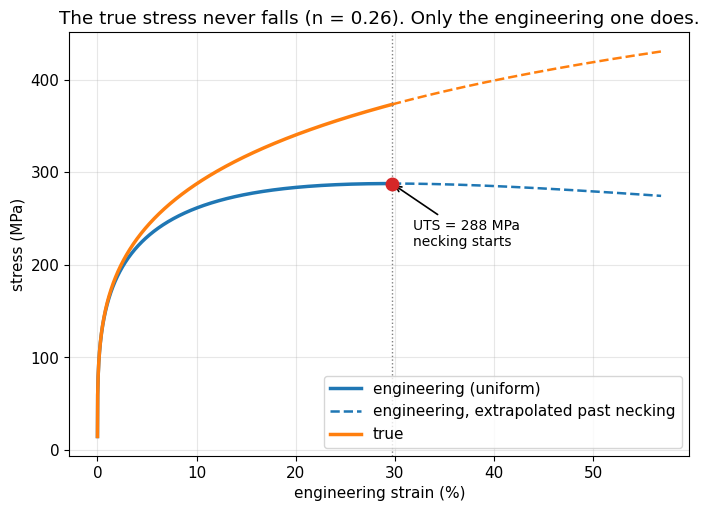


true eps at necking = 0.260  (= n = 0.26)
Beyond the red dot the curves are DASHED because they are no longer measurable:
they still assume uniform deformation, while the real specimen has a neck, one
section carrying everything, and A0 no longer describes anything.


In [6]:
K_H = 530e6    # Hollomon strength coefficient, Pa. NOT K, which is the bulk modulus.

print(f"{'n':>6}{'eps_neck (solved)':>20}{'equals n?':>11}"
      f"{'UTS_eng (MPa)':>16}{'K_H n^n e^-n':>13}")
for n in (0.05, 0.10, 0.26, 0.45):
    S_t  = lambda e: K_H*e**n
    dS_t = lambda e: K_H*n*e**(n-1)
    e_neck = brentq(lambda e: dS_t(e) - S_t(e), 1e-4, 3.0)
    uts = S_t(e_neck)*np.exp(-e_neck)          # back to engineering at necking
    print(f"{n:6.2f}{e_neck:20.6f}{'yes' if abs(e_neck-n) < 1e-8 else 'NO':>11}"
          f"{uts/1e6:16.1f}{K_H*n**n*np.exp(-n)/1e6:13.1f}")

# the two curves, side by side, for one material
n = 0.26
et = np.linspace(1e-6, 0.45, 2000)
S_true = K_H*et**n
ee, S_eng = np.exp(et) - 1, S_true*np.exp(-et)
i_uts = np.argmax(S_eng)

fig, ax = plt.subplots(figsize=(8, 5.5))
# Solid up to necking, dashed after: past eps_t = n these formulas still assume UNIFORM
# deformation, so the dashed part is what a non-necking material would have done, not
# what the machine records once a neck forms.
ax.plot(ee[:i_uts+1]*100, S_eng[:i_uts+1]/1e6, lw=2.5, color='tab:blue',
        label='engineering (uniform)')
ax.plot(ee[i_uts:]*100, S_eng[i_uts:]/1e6, lw=1.8, ls='--', color='tab:blue',
        label='engineering, extrapolated past necking')
ax.plot(ee[:i_uts+1]*100, S_true[:i_uts+1]/1e6, lw=2.5, color='tab:orange', label='true')
ax.plot(ee[i_uts:]*100, S_true[i_uts:]/1e6, lw=1.8, ls='--', color='tab:orange')
ax.plot(ee[i_uts]*100, S_eng[i_uts]/1e6, 'o', color='tab:red', ms=9, zorder=5)
ax.annotate(f'UTS = {S_eng[i_uts]/1e6:.0f} MPa\nnecking starts',
            xy=(ee[i_uts]*100, S_eng[i_uts]/1e6), xytext=(15, -45),
            textcoords='offset points', fontsize=10,
            arrowprops=dict(arrowstyle='->', lw=1.2))
ax.axvline(ee[i_uts]*100, color='grey', ls=':', lw=1)
ax.set_xlabel('engineering strain (%)'); ax.set_ylabel('stress (MPa)')
ax.set_title(f'The true stress never falls (n = {n}). Only the engineering one does.')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print(f"\ntrue eps at necking = {et[i_uts]:.3f}  (= n = {n})")
print("Beyond the red dot the curves are DASHED because they are no longer measurable:")
print("they still assume uniform deformation, while the real specimen has a neck, one")
print("section carrying everything, and A0 no longer describes anything.")

---
## 7. Four questions, four different answers

The same curve is read for four properties that get casually conflated:

| property | what it is | read from |
|---|---|---|
| **stiffness** | resistance to *elastic* deformation | slope $E$ |
| **strength** | stress the material can carry | $S_y$, $S_u$ |
| **ductility** | how much it deforms before fracture | $\varepsilon_f$, area reduction |
| **toughness** | energy absorbed per unit volume | **area under the curve** |

They are independent, and they do not rank materials the same way. The four materials in
the cell below carry **representative** values, assembled to compare properties: they are
teaching numbers, not design allowables, and nothing in this course is qualified on them. Two consequences
worth carrying into the course:

- **Stiffness is not strength.** Every steel here has $E \approx 200$ GPa whether it
  yields at 250 or at 1000 MPa. $E$ is set by interatomic bonding; yield strength is set
  by obstacles to dislocation motion. Heat-treating a steel changes the second by a
  factor of four and the first by essentially nothing.
- **Strength is not toughness.** Toughness needs stress *and* strain, so a strong brittle
  material can absorb far less energy than a weaker ductile one - and the ranking is not
  the reverse of strength either, as the table below shows. Two cautions before this is
  carried into reactor work. The area under a tensile curve is **tensile toughness**; the
  quantities that govern brittle fracture are $K_{Ic}$ and the Charpy energy, measured on
  notched or cracked specimens, and they are not this number. And a reactor pressure
  vessel is **not** austenitic: it is a low-alloy ferritic steel, SA-508 or SA-533, with a
  thin austenitic cladding inside for corrosion. The ductile-to-brittle transition the
  course returns to belongs to those ferritic steels, which are body-centred cubic;
  austenitic steels are face-centred cubic and have no such transition.

In [7]:
# Representative datasheet values: (E GPa, Sy, Su MPa, uniform elongation, elongation
# at fracture). NOTE these curves are interpolated through measured anchor points, NOT
# generated from a constitutive law. A single Hollomon power law cannot pass through
# the 0.2 % offset AND predict a realistic UTS at the same time, and forcing it to do both
# gives a mild steel with a 642 MPa UTS.
# For a comparison of PROPERTIES, honest anchor points beat a law that does not fit.
mats = [("mild steel S235",     210,  235,  400, 0.18, 0.30),   # S235: the 235 IS the grade
        ("AISI 304 austenitic", 193,  250,  600, 0.45, 0.55),
        ("high-strength steel", 200, 1000, 1100, 0.06, 0.08),
        ("Al alloy 6061-T6",     69,  275,  310, 0.10, 0.15)]

def eng_curve(E, sy, su, eu, ef, N=4000):
    E, sy, su = E*1e9, sy*1e6, su*1e6
    ey = sy/E
    e1 = np.linspace(0, ey, 200);      s1 = E*e1                       # elastic
    e2 = np.linspace(ey, eu, N)                                        # hardening
    s2 = sy + (su - sy)*((e2 - ey)/(eu - ey))**0.5
    e3 = np.linspace(eu, ef, 400)                                      # after necking
    s3 = su - 0.15*su*(e3 - eu)/(ef - eu)
    return np.concatenate([e1, e2, e3]), np.concatenate([s1, s2, s3])

print(f"{'material':<22}{'E(GPa)':>8}{'Sy(MPa)':>9}{'Su(MPa)':>9}"
      f"{'eps_u':>7}{'eps_f':>7}{'toughness (MJ/m3)':>19}")
res, curves = [], {}
for name, Eg, syM, suM, eu, ef in mats:
    e, s = eng_curve(Eg, syM, suM, eu, ef)
    tough = trapz(s, e)/1e6
    res.append((name, Eg, syM, suM, ef, tough))
    curves[name] = (e, s)
    print(f"{name:<22}{Eg:>8}{syM:>9}{suM:>9}{eu:>7.2f}{ef:>7.2f}{tough:>19.1f}")

hs = [r for r in res if r[0].startswith('high')][0]
au = [r for r in res if '304' in r[0]][0]
ms = [r for r in res if r[0].startswith('mild')][0]
print(f"\nThe three steels: E = 193-210 GPa, yield 235 -> 1000 MPa.")
print(f"  Stiffness barely moves while strength quadruples. Different physics:")
print(f"  E is interatomic bonding, Sy is obstacles to dislocation motion.")
print(f"\nHigh-strength steel yields at {hs[2]/au[2]:.1f}x the austenitic one and"
      f" {hs[2]/ms[2]:.1f}x the mild one,")
print(f"  yet absorbs {100*hs[5]/au[5]:.0f} % of the austenitic's energy and"
      f" {100*hs[5]/ms[5]:.0f} % of the mild steel's.")
print(f"  Toughest of the four: {max(res, key=lambda r: r[5])[0]}")
print(f"  Strength ranks them {' > '.join(r[0].split()[0] for r in sorted(res, key=lambda r: -r[2]))}")
print(f"  Toughness ranks them {' > '.join(r[0].split()[0] for r in sorted(res, key=lambda r: -r[5]))}")
print("  -> not the same order, and not the reverse order either.")

material                E(GPa)  Sy(MPa)  Su(MPa)  eps_u  eps_f  toughness (MJ/m3)
mild steel S235            210      235      400   0.18   0.30              106.2
AISI 304 austenitic        193      250      600   0.45   0.55              272.5
high-strength steel        200     1000     1100   0.06   0.08               81.5
Al alloy 6061-T6            69      275      310   0.10   0.15               43.5

The three steels: E = 193-210 GPa, yield 235 -> 1000 MPa.
  Stiffness barely moves while strength quadruples. Different physics:
  E is interatomic bonding, Sy is obstacles to dislocation motion.

High-strength steel yields at 4.0x the austenitic one and 4.3x the mild one,
  yet absorbs 30 % of the austenitic's energy and 77 % of the mild steel's.
  Toughest of the four: AISI 304 austenitic
  Strength ranks them high-strength > Al > AISI > mild
  Toughness ranks them AISI > mild > high-strength > Al
  -> not the same order, and not the reverse order either.


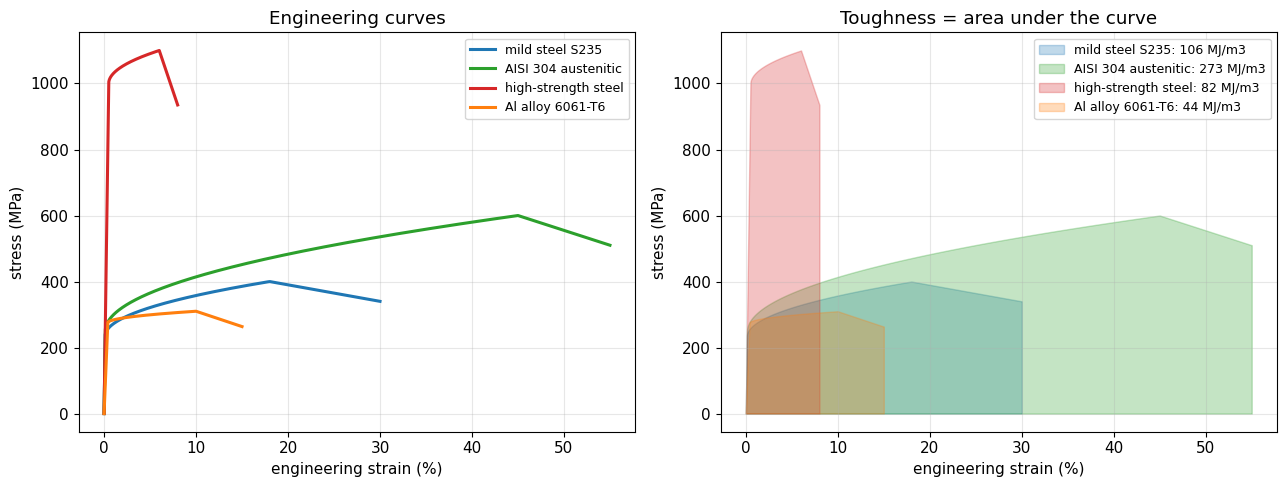

The red curve is by far the highest and the SMALLEST in area of the three steels.
Height is strength. Area is toughness. They are different questions.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cols = ['tab:blue', 'tab:green', 'tab:red', 'tab:orange']
for (name, _, _, _, _, tough), c in zip(res, cols):
    e_eng, S_eng = curves[name]
    axes[0].plot(e_eng*100, S_eng/1e6, lw=2.2, color=c, label=name)
    axes[1].fill_between(e_eng*100, S_eng/1e6, alpha=0.28, color=c,
                         label=f'{name}: {tough:.0f} MJ/m3')
axes[0].set_xlabel('engineering strain (%)'); axes[0].set_ylabel('stress (MPa)')
axes[0].set_title('Engineering curves'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('engineering strain (%)'); axes[1].set_ylabel('stress (MPa)')
axes[1].set_title('Toughness = area under the curve')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("The red curve is by far the highest and the SMALLEST in area of the three steels.")
print("Height is strength. Area is toughness. They are different questions.")

---
## 8. Idealised models, and what each one throws away

A full Ramberg-Osgood or Hollomon law is rarely what you calculate with. Design work
uses idealisations, and the useful question is not "which is most accurate" but
**"what does this one discard, and does discarding it fall on the safe side?"**

The cell below takes **Ludwik**, $\sigma = S_y + K_L\varepsilon_p^{\,n}$, as the reference
curve rather than the Hollomon of §6. Ludwik starts at $S_y$ instead of at zero, which is
what lets it be compared against a perfectly plastic line over the whole plastic range;
§6's own caveat says why Hollomon cannot play that part.

| model | keeps | discards |
|---|---|---|
| rigid, perfectly plastic | the yield plateau | all elasticity |
| **linear elastic, perfectly plastic (LEPP)** | $E$ and $S_y$ | **all hardening** |
| linear hardening | $E$, $S_y$, a mean slope | the curvature |
| Ramberg-Osgood / Hollomon / Ludwik | the real shape | closed-form simplicity |

LEPP is the workhorse of this course: limit analysis, plastic collapse, the shape
factor, the whole ASME machinery. It sits below the real curve **at the strains that
govern collapse**, so for a **strength** calculation it under-predicts capacity:
conservative, which is why it is allowed. Not everywhere, though: near the knee, between
the proportional limit and $R_{p0.2}$, the slope of the real curve has already begun to fall while LEPP's has not, and there LEPP sits *above*. That is the next paragraph.

**But watch what happens when the failure mode changes.** For buckling the same
assumption turns out to be *unconservative*, because there what matters is
not the stress the material can carry but the **stiffness** $E_t = d\sigma/d\varepsilon$
that resists further bending. LEPP's sharp corner over-states $E_t$ **just below** $S_y$.
That is not where a *slender* column fails - a slender one buckles elastically, far below
$S_y$, where $E_t = E$ and LEPP is exact. It is where a column of **intermediate
slenderness** fails, in the inelastic range. Above
$S_y$ LEPP gives $E_t = 0$, which is conservative again. The sign of the error turns on
the stress level as well as on the failure mode.

**An idealisation is not conservative in itself. It is conservative with respect to a
particular failure mode.**

LEPP (no hardening)      plastic work, signed error:  -23.4 %
linear hardening         plastic work, signed error:   -8.6 %

peak true stress: real 346 MPa, LEPP 250 MPa -> LEPP is 28 % low
Both errors are negative HERE, on a law with no knee: at these strains the
idealisation under-predicts the capacity, which is what makes it usable.
Near the knee it does not - see the markdown above. For STRENGTH, low is safe.
For BUCKLING, just below Sy, it will not be.


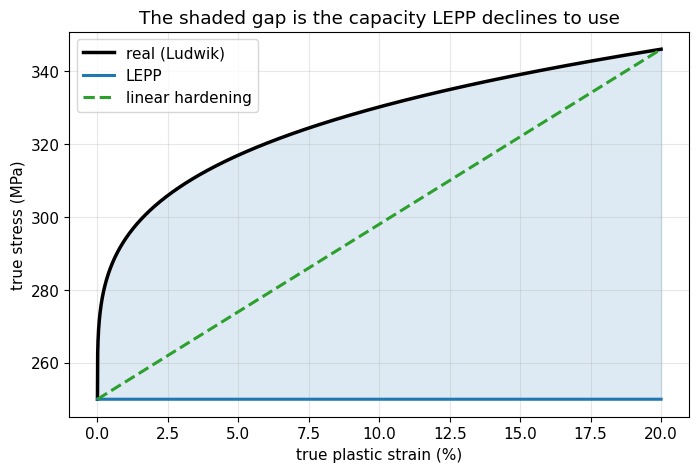

In [9]:
# Ludwik/Swift, sigma = Sy + K_L eps_p^n, and NOT Hollomon. Hollomon has no elastic
# branch and starts from zero, so with K_H = 530 MPa it stays BELOW the 250 MPa of LEPP
# until eps_p = 5.6 % - a quarter of this plot - and the shaded area would then mean the
# opposite of the title. Section 6 says the same thing about Hollomon's range. K_L is
# picked for a mild hardener: 346 MPa at 20 % plastic strain, well below the S235 of
# section 7. One caveat against section 5: in this law Sy is the stress at eps_p = 0, the INITIAL yield,
# not the 0.2 % offset. At eps_p = 0.002 the curve already reads 279 MPa.
Em, sym, K_L, n_L, efm = 200e9, 250e6, 146e6, 0.26, 0.20
e = np.linspace(0.0, efm, 5000)               # plastic strain
S_real = sym + K_L*e**n_L
S_lepp = np.full_like(e, sym)
H = (S_real[-1] - sym)/efm                    # linear hardening matched at the end
S_lin = sym + H*e
assert np.all(S_lepp <= S_real + 1e-9), "LEPP must never exceed the real curve here"

W_real = trapz(S_real, e)
for lab, S in (("LEPP (no hardening)", S_lepp), ("linear hardening", S_lin)):
    print(f"{lab:<24} plastic work, signed error: "
          f"{100*(trapz(S, e) - W_real)/W_real:+6.1f} %")
print(f"\npeak true stress: real {S_real.max()/1e6:.0f} MPa,"
      f" LEPP {sym/1e6:.0f} MPa -> LEPP is {100*(1-sym/S_real.max()):.0f} % low")
print("Both errors are negative HERE, on a law with no knee: at these strains the")
print("idealisation under-predicts the capacity, which is what makes it usable.")
print("Near the knee it does not - see the markdown above. For STRENGTH, low is safe.")
print("For BUCKLING, just below Sy, it will not be.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(e*100, S_real/1e6, lw=2.5, color='k', label='real (Ludwik)')
ax.plot(e*100, S_lepp/1e6, lw=2.2, color='tab:blue', label='LEPP')
ax.plot(e*100, S_lin/1e6, lw=2.2, color='tab:green', ls='--', label='linear hardening')
ax.fill_between(e*100, S_lepp/1e6, S_real/1e6, color='tab:blue', alpha=0.15)
ax.set_xlabel('true plastic strain (%)'); ax.set_ylabel('true stress (MPa)')
ax.set_title('The shaded gap is the capacity LEPP declines to use')
ax.legend(); ax.grid(alpha=0.3)
import os
# Export for the course notes: a no-op unless the author's environment variable is set.
_cn = os.environ.get("NDT_COURSE_NOTES_FIGURES", "")
if os.path.isdir(_cn):
    plt.savefig(os.path.join(_cn, "03_idealised_models.pdf"), bbox_inches="tight")
plt.show()

---
## 9. Two limits of the tensile test

The test is **uniaxial**. Real components are not. Two facts carry across.

**Tension and compression are not mirror images.** For a ductile metal they are close
enough that one curve serves for both. For a **brittle** material they are wildly
different: a grey cast iron or a ceramic can be several times stronger in compression
than in tension, because failure is by cleavage across the plane of maximum normal
*tensile* stress. Compression does not open cleavage planes, and such a material fails
there by shear on inclined planes instead. A single "strength" number is therefore
meaningless for it. This is why a *second* family of criteria is needed: Tresca and von
Mises for ductile metals, **Galileo-Rankine** for brittle ones, which switches the
governing quantity from shear to the maximum normal stress. Note what that switch does
*not* do on its own: with a single threshold it still cannot express
$\sigma_t \ne \sigma_c$. Two thresholds, or a Mohr-Coulomb envelope, are what the
asymmetry actually needs.

**For a dense metal, yielding does not care about hydrostatic stress.** Squeeze a metal equally from all
sides and, to an excellent approximation, it will not yield: there is no shear anywhere, and plastic
flow is dislocation glide, which needs shear. Only the **deviatoric** part of the stress
(the part left after removing $\tfrac13\sigma_{kk}\delta_{ij}$) drives
yielding. This is measured, not assumed: in the 1950s Bridgman ran tensile tests inside
a pressure chamber at up to 25 000 atmospheres, about 2.5 GPa, and the yield stress barely
moved (reported in Corradi Dell'Acqua, §3.3.3).

Together these say the uniaxial $S_y$ is not directly comparable to a multiaxial stress
state. You need a rule that maps a tensor onto one number that *can* be compared with
$S_y$. That rule is a **failure criterion**.

In [10]:
# Yielding ignores hydrostatic stress. NOTE the sign: these notebooks are
# tension-positive, so adding +p to the diagonal adds TENSION. A pressure of
# 500 MPa would be -500 on the diagonal.
sig = np.diag([180e6, 60e6, -40e6])              # some triaxial state, Pa
def deviator(S):
    return S - np.trace(S)/3*np.eye(3)
def von_mises(S):
    d = deviator(S)
    return np.sqrt(1.5*np.sum(d*d))

print(f"{'added hydrostatic stress':>26}{'trace/3 (MPa)':>16}{'von Mises (MPa)':>18}")
for p in (0, 100e6, 500e6, -300e6):
    S = sig + p*np.eye(3)
    print(f"{p/1e6:26.0f}{np.trace(S)/3/1e6:16.1f}{von_mises(S)/1e6:18.4f}")

print("\nThe mean stress moves by 800 MPa. The von Mises stress does not move at all.")
print("A criterion built on it therefore predicts the same distance from yielding,")
print("which is what experiments on metals actually show.")

  added hydrostatic stress   trace/3 (MPa)   von Mises (MPa)
                         0            66.7          190.7878
                       100           166.7          190.7878
                       500           566.7          190.7878
                      -300          -233.3          190.7878

The mean stress moves by 800 MPa. The von Mises stress does not move at all.
A criterion built on it therefore predicts the same distance from yielding,
which is what experiments on metals actually show.


---
## 10. Exercises

The first four follow §1-§3 (the elastic law); the rest follow §4-§9 (the tensile test).

**E1. Moduli.** Starting from $\sigma_{ij} = \lambda\varepsilon_{kk}\delta_{ij}
+ 2G\varepsilon_{ij}$, derive $G = E/[2(1+\nu)]$ by considering pure shear, and
$K = E/[3(1-2\nu)]$ by considering hydrostatic loading.

**E2. Which plane assumption?** For each, say which of the three you would use and why:
(a) a thin plate with in-plane loads; (b) a long buried pipe encased in concrete;
(c) a reactor vessel cylinder far from its heads; (d) the **wall** of a thin-walled
tube with free ends, and then the same tube's **cross-section**. The last one is two
different answers, and saying why is the point.

**E3. The cost of the wrong choice.** Redo §2 using plane strain where generalised
plane strain is correct. How large is the error in $\sigma_{zz}$? Is it conservative? Do
it twice, once for a temperature gradient and once for internal pressure, and explain why
the two answers have opposite signs.

**E4. The biaxial modulus.** Derive $\sigma = \frac{E}{1-\nu}(\varepsilon - \alpha\Delta T)$
from the full 3-D law without looking at §3, stating each assumption as you use it.

**E5. Where the conversion dies.** A specimen shows 25 % engineering elongation at
fracture. Convert to true strain. Then explain why the conversion formula you just used
is *not* legitimate at that point, and what you would need to measure instead.

**E6. Offset by hand.** Take the Ramberg-Osgood law of §5 with $n = 20$ instead of 10.
Sketch what changes. Does $R_{p0.2}$ move? Does the *shape* of the knee move? Which of
the two is $n$ actually controlling?

**E7. Considère both ways.** Show analytically that for $\sigma_t = K_H\varepsilon_t^n$
the engineering UTS is $S_u = K_H n^n e^{-n}$. Then compute $S_u$ for $n = 0.1$ and
$n = 0.4$ with the same $K_H$. Which material has the higher UTS, and which one can be
drawn further before necking? Are these the same material?

**E8. Choosing for a vessel.** From the table in §7, and justifying each answer with the
*specific property* that decides it, not with "it is stronger": (a) which material for the
wall of a **non-nuclear** pressure vessel? (b) which for a bolt that must not **yield**
under its preload? (c) which for a bolt that must not **stretch elastically**? That one
is a trap, and the table says why. (d) None of the four is a reactor pressure vessel
steel: say what an RPV needs that none of them offers, and why no column of this table
could have told you.

**E9. Where the idealisation bites.** A component is checked for (a) plastic collapse
under pressure and (b) buckling under an axial compressive load, both using LEPP. In
which case is the assumption conservative? Explain the difference in terms of *which
feature of the curve* each failure mode is sensitive to.

**E10. Two numbers for a brittle material.** Section 9 says a brittle material can be
several times stronger in compression than in tension. Explain why, in terms of the
mechanism that fails in each case. Then say what goes wrong if such a component is
checked with a single strength value and a von Mises stress: which of the two loadings
would that check declare safe when it is not?
